In [24]:
# Install geospatial, ML, and plotting libraries
!pip install rasterio rioxarray xarray geopandas matplotlib seaborn scikit-learn netCDF4 folium


In [25]:
# Standard libraries
import os
import numpy as np
import pandas as pd

# Geospatial libraries
import rasterio
import rioxarray
import xarray as xr
import geopandas as gpd
from shapely.geometry import box
from rasterio.warp import transform_bounds
import folium

# ML and plotting
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [26]:
# Mount Google Drive to access SOC and AGB files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# Update paths according to your Google Drive structure
soc_path = "/content/drive/MyDrive/SOCEO/SOC.tif"
agb_path = "/content/drive/MyDrive/SOCEO/ESACCI-BIOMASS-L4-AGB-MERGED-1000m-fv6.0.nc"

# Check if files exist
for p in [soc_path, agb_path]:
    print("Found:" if os.path.exists(p) else " Missing:", p)


Found: /content/drive/MyDrive/SOCEO/SOC.tif
Found: /content/drive/MyDrive/SOCEO/ESACCI-BIOMASS-L4-AGB-MERGED-1000m-fv6.0.nc


In [29]:
# Load SOC raster using rioxarray
soc_raster = rioxarray.open_rasterio(soc_path)
print("SOC raster info:")
print(soc_raster)
print("SOC CRS:", soc_raster.rio.crs)
print("AGB coords:", list(agb_ds.coords))

SOC raster info:
<xarray.DataArray (band: 1, y: 454, x: 378)> Size: 343kB
[171612 values with dtype=int16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 4kB 5.574e+06 5.574e+06 ... 5.461e+06 5.461e+06
  * x            (x) float64 3kB 1.606e+06 1.606e+06 ... 1.7e+06 1.7e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     72
    TIFFTAG_YRESOLUTION:     72
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
SOC CRS: PROJCS["Interrupted_Goode_Homolosine",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Interrupted_Goode_Homolosine"],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
AGB coords: ['lon', 'lat', 'time']


In [30]:
# open dataset
agb_ds = xr.open_dataset(agb_path)
print("AGB variables:", list(agb_ds.data_vars))
print("AGB coords:", list(agb_ds.coords))

# detect coordinate names
lat_name = "lat" if "lat" in agb_ds.coords else "latitude"
lon_name = "lon" if "lon" in agb_ds.coords else "longitude"

# flip latitude if descending
if agb_ds[lat_name][0] > agb_ds[lat_name][-1]:
    agb_ds = agb_ds.reindex({lat_name: list(reversed(agb_ds[lat_name]))})

# convert SOC extent to lat/lon
soc_bounds_utm = soc_raster.rio.bounds()
soc_bounds_latlon = transform_bounds(soc_raster.rio.crs, "EPSG:4326", *soc_bounds_utm)
minx, miny, maxx, maxy = soc_bounds_latlon
print("SOC bounds (lat/lon):", soc_bounds_latlon)

# crop AGB dataset around SOC extent
agb_small = agb_ds.sel(
    {lat_name: slice(miny - 0.2, maxy + 0.2),
     lon_name: slice(minx - 0.2, maxx + 0.2)}
)

print("Subset shape:", agb_small[lat_name].size, agb_small[lon_name].size)
if agb_small[lat_name].size == 0 or agb_small[lon_name].size == 0:
    raise ValueError("No data found in AGB dataset for SOC extent.")

# assign CRS and select AGB variable
agb_small = agb_small.rio.write_crs("EPSG:4326", inplace=True)
var_name = [v for v in agb_small.data_vars if "agb" in v.lower()][0]

# reproject to SOC grid
agb_crop = agb_small[var_name].rio.reproject_match(soc_raster)
print("Cropped & reprojected AGB subset.")
print(agb_crop)


AGB variables: ['agb', 'agb_sd', 'crs', 'lon_bnds', 'lat_bnds', 'time_bnds']
AGB coords: ['lon', 'lat', 'time']
SOC bounds (lat/lon): (7.095317589394664, 49.27964364986537, 8.64664670265765, 50.36152051298947)
Subset shape: 148 195
Cropped & reprojected AGB subset.
<xarray.DataArray 'agb' (time: 10, y: 454, x: 378)> Size: 7MB
array([[[190., 185., 185., ..., 116., 116., 191.],
        [226., 213., 213., ..., 138., 138., 174.],
        [226., 213., 213., ..., 138., 174., 174.],
        ...,
        [134., 134., 115., ...,  67., 106., 106.],
        [134., 115., 115., ...,  67., 106., 106.],
        [134., 115., 115., ...,  67., 106., 106.]],

       [[193., 188., 188., ..., 110., 110., 186.],
        [220., 213., 213., ..., 135., 135., 174.],
        [220., 213., 213., ..., 135., 174., 174.],
        ...,
        [127., 127., 110., ...,  72., 120., 120.],
        [127., 110., 110., ...,  72., 120., 120.],
        [127., 110., 110., ...,  72., 120., 120.]],

       [[186., 186., 186., ...

In [31]:
# Draw SOC raster bounds on a map
soc_box = box(minx, miny, maxx, maxy)
gdf = gpd.GeoDataFrame(geometry=[soc_box], crs="EPSG:4326")

# Display with folium
m = folium.Map(location=[(miny+maxy)/2, (minx+maxx)/2], zoom_start=6)
folium.GeoJson(gdf, name="SOC extent",
               style_function=lambda x: {'color':'red','fill':False}).add_to(m)
m


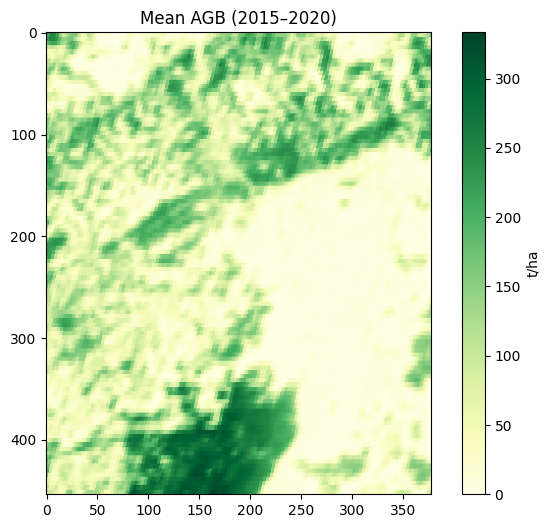

In [32]:
# Average AGB over the time dimension
agb_mean = agb_crop.mean(dim="time")

# Plot mean AGB
plt.figure(figsize=(8,6))
plt.imshow(agb_mean.squeeze(), cmap="YlGn")
plt.title("Mean AGB (2015–2020)")
plt.colorbar(label="t/ha")
plt.show()


In [33]:
# Flatten array for clustering
X = agb_mean.values.flatten()
mask = ~np.isnan(X)
X = X[mask].reshape(-1,1)

# Apply KMeans clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# Evaluate cluster quality
score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.3f}")


Silhouette Score: 0.620


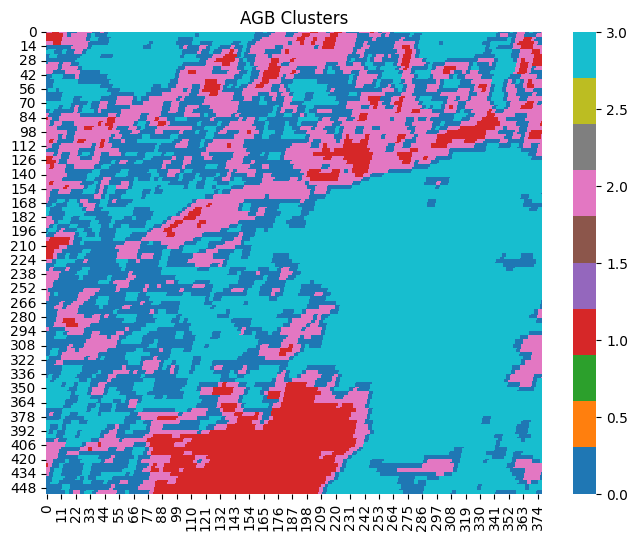

In [35]:
cluster_map = np.full(agb_mean.shape, np.nan)
flat = cluster_map.flatten()
flat[mask] = labels
cluster_map = flat.reshape(agb_mean.shape)

# Plot cluster map
plt.figure(figsize=(8,6))
sns.heatmap(cluster_map, cmap="tab10")
plt.title("AGB Clusters")
plt.show()


Mean SOC per AGB Cluster: [np.float64(50.76318412271959), np.float64(61.95127683902935), np.float64(56.19451364086557), np.float64(38.96338861473618)]


/tmp/ipython-input-3128825760.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(n_clusters)), y=mean_soc_per_cluster, palette="viridis")


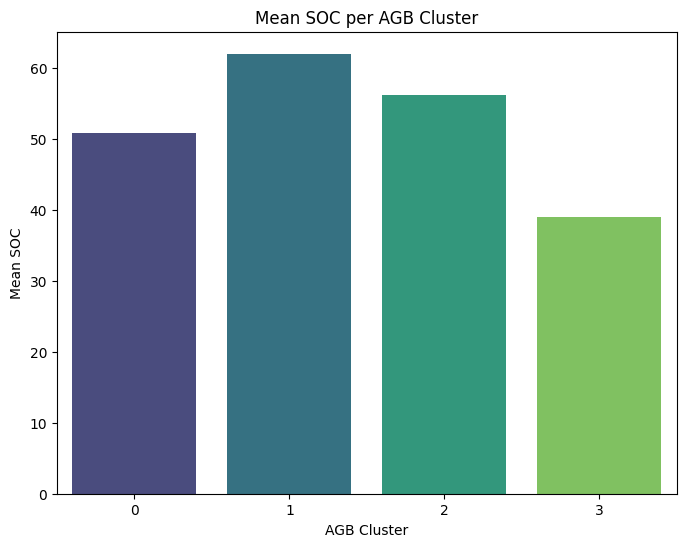

In [36]:
soc_values = soc_raster.values.flatten()
cluster_values = cluster_map.flatten()

# Only consider valid pixels
valid = ~np.isnan(soc_values) & ~np.isnan(cluster_values)
soc_valid = soc_values[valid]
cluster_valid = cluster_values[valid]

# Compute mean SOC per cluster
mean_soc_per_cluster = [soc_valid[cluster_valid == i].mean() for i in range(n_clusters)]
print("Mean SOC per AGB Cluster:", mean_soc_per_cluster)

# Plot mean SOC per cluster
plt.figure(figsize=(8,6))
sns.barplot(x=list(range(n_clusters)), y=mean_soc_per_cluster, palette="viridis")
plt.xlabel("AGB Cluster")
plt.ylabel("Mean SOC")
plt.title("Mean SOC per AGB Cluster")
plt.show()


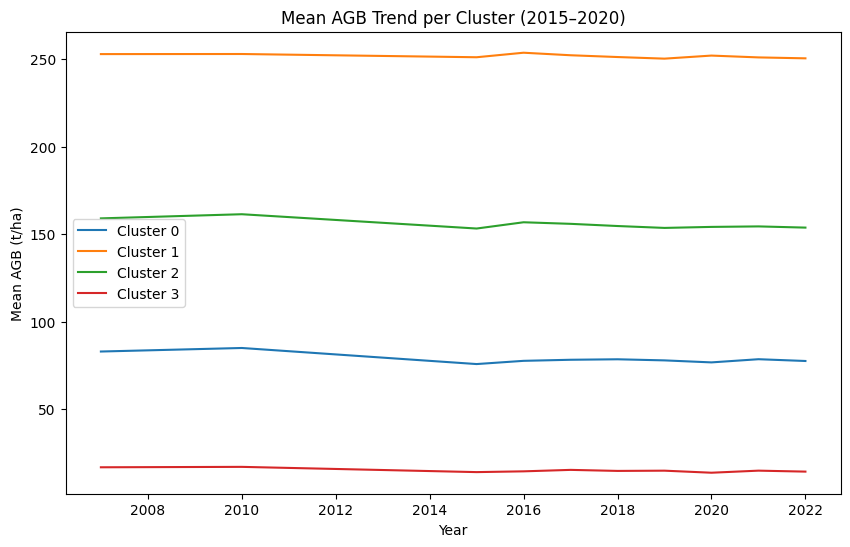

In [34]:
#Visualize mean AGB trend over time for each cluster
time_dim = agb_crop["time"]
plt.figure(figsize=(10,6))

for i in range(n_clusters):
    mask_cluster = cluster_map == i
    agb_trend = agb_crop.where(mask_cluster).mean(dim=("x","y"))
    plt.plot(time_dim, agb_trend, label=f"Cluster {i}")

plt.xlabel("Year")
plt.ylabel("Mean AGB (t/ha)")
plt.title("Mean AGB Trend per Cluster (2015–2020)")
plt.legend()
plt.show()


In [41]:
#Answer conceptual questions

report = """
Q1 – How would you utilize additional soil properties?
"Adding soil texture (sand, silt, clay), pH, moisture, and bulk density "
"provides biophysical context for SOC dynamics. These variables affect carbon "
"stabilization and decomposition, so including them as features in ML models "
"can improve SOC prediction accuracy and reduce regional bias."


Q2 – Benefits and challenges of combining low-resolution weather and high-resolution land-use data:
"Low-resolution weather data (temperature, rainfall) captures broad climatic "
"drivers, while high-resolution land-use data reflects management practices. "
"Integrating both improves SOC predictions by linking climate and local factors. "
"However, mismatched spatial scales require careful resampling, which may "
"introduce noise and increase computational load if not handled properly."

"""
print(report)




Q1 – How would you utilize additional soil properties?
"Adding soil texture (sand, silt, clay), pH, moisture, and bulk density "
"provides biophysical context for SOC dynamics. These variables affect carbon "
"stabilization and decomposition, so including them as features in ML models "
"can improve SOC prediction accuracy and reduce regional bias."


Q2 – Benefits and challenges of combining low-resolution weather and high-resolution land-use data:
"Low-resolution weather data (temperature, rainfall) captures broad climatic "
"drivers, while high-resolution land-use data reflects management practices. "
"Integrating both improves SOC predictions by linking climate and local factors. "
"However, mismatched spatial scales require careful resampling, which may "
"introduce noise and increase computational load if not handled properly."


